In [1]:
import numpy as np
import pandas as pd

In [5]:
all_data_df = pd.read_csv('/workspaces/py_spec/Lysozyme/26-02-20 15-51-31 Absorbance Spectra.CSV', skiprows=5)
print(all_data_df.head())

  Well          Content  \
0  NaN  Wavelength [nm]   
1  B01        Sample X1   
2  B02        Sample X2   
3  B03        Sample X3   
4  B04        Sample X4   

   Average over replicates based on Blank corrected (Abs Spectrum)  \
0                                            220.000                 
1                                              0.424                 
2                                              0.379                 
3                                              0.107                 
4                                              0.388                 

   Average over replicates based on Blank corrected (Abs Spectrum).1  \
0                                            221.000                   
1                                              0.455                   
2                                              0.411                   
3                                              0.113                   
4                                              0.429    

In [6]:
# Extract different data types based on column headers
# Get the column names
columns = all_data_df.columns.tolist()

# Find where each section starts based on the column headers
avg_blank_corrected_cols = [i for i, col in enumerate(columns) if 'Average over replicates' in str(col)]
blank_corrected_cols = [i for i, col in enumerate(columns) if 'Blank corrected based on Raw Data' in str(col)]
raw_data_cols = [i for i, col in enumerate(columns) if 'Raw Data (Abs Spectrum)' in str(col) and 'Blank corrected' not in str(col)]

# Extract metadata columns (Well, Content)
metadata_cols = [0, 1]

# Create separate dataframes
# Average blank corrected
avg_blank_corrected_df = all_data_df.iloc[:, metadata_cols + avg_blank_corrected_cols].copy()
avg_blank_corrected_df.columns = ['Well', 'Content'] + [f'nm_{220+i}' for i in range(len(avg_blank_corrected_cols))]

# Blank corrected
blank_corrected_df = all_data_df.iloc[:, metadata_cols + blank_corrected_cols].copy()
blank_corrected_df.columns = ['Well', 'Content'] + [f'nm_{220+i}' for i in range(len(blank_corrected_cols))]

# Raw data
raw_df = all_data_df.iloc[:, metadata_cols + raw_data_cols].copy()
raw_df.columns = ['Well', 'Content'] + [f'nm_{220+i}' for i in range(len(raw_data_cols))]

print(f"Average blank corrected shape: {avg_blank_corrected_df.shape}")
print(f"Blank corrected shape: {blank_corrected_df.shape}")
print(f"Raw data shape: {raw_df.shape}")
print("\nAverage blank corrected preview:")
print(avg_blank_corrected_df.head())
print("\nBlank corrected preview:")
print(blank_corrected_df.head())
print("\nRaw data preview:")
print(raw_df.head())

Average blank corrected shape: (37, 783)
Blank corrected shape: (37, 783)
Raw data shape: (37, 783)

Average blank corrected preview:
  Well          Content   nm_220   nm_221   nm_222   nm_223   nm_224   nm_225  \
0  NaN  Wavelength [nm]  220.000  221.000  222.000  223.000  224.000  225.000   
1  B01        Sample X1    0.424    0.455    0.505    0.621    0.690    0.852   
2  B02        Sample X2    0.379    0.411    0.505    0.639    0.633    0.820   
3  B03        Sample X3    0.107    0.113    0.168    0.244    0.260    0.387   
4  B04        Sample X4    0.388    0.429    0.522    0.613    0.667    0.856   

    nm_226   nm_227  ...   nm_991   nm_992   nm_993   nm_994   nm_995  \
0  226.000  227.000  ...  991.000  992.000  993.000  994.000  995.000   
1    0.964    1.170  ...    0.132    0.145    0.151    0.152    0.151   
2    0.995    1.136  ...    0.140    0.154    0.162    0.163    0.162   
3    0.523    0.625  ...    0.094    0.079    0.051    0.051    0.055   
4    0.971    

In [8]:
# Create concentration mapping for samples
concentration_map = {
    'Sample X1': 10.0,
    'Sample X2': 9.0,
    'Sample X3': 8.0,
    'Sample X4': 7.0,
    'Sample X5': 6.0,
    'Sample X6': 5.0,
    'Sample X7': 4.0,
    'Sample X8': 3.0,
    'Sample X9': 2.0,
    'Sample X10': 1.0,
    'Sample X11': 0.1,
    'Sample X12': 0.0  # Blank
}

# Replace Content column with concentration values
blank_corrected_df['Content'] = blank_corrected_df['Content'].map(concentration_map)

print("Blank corrected data with concentrations:")
print(blank_corrected_df[['Well', 'Content']].head(15))
print(f"\nFull dataframe shape: {blank_corrected_df.shape}")
print("\nPreview of data:")
print(blank_corrected_df.head())

Blank corrected data with concentrations:
   Well  Content
0   NaN      NaN
1   B01     10.0
2   B02      9.0
3   B03      8.0
4   B04      7.0
5   B05      6.0
6   B06      5.0
7   B07      4.0
8   B08      3.0
9   B09      2.0
10  B10      1.0
11  B11      0.1
12  B12      NaN
13  C01     10.0
14  C02      9.0

Full dataframe shape: (37, 784)

Preview of data:
  Well  Content  Concentration_mg_ml   nm_220   nm_221   nm_222   nm_223  \
0  NaN      NaN                  NaN  220.000  221.000  222.000  223.000   
1  B01     10.0                 10.0    0.384    0.426    0.459    0.596   
2  B02      9.0                  9.0    0.342    0.394    0.544    0.653   
3  B03      8.0                  8.0    0.409    0.410    0.490    0.624   
4  B04      7.0                  7.0    0.435    0.482    0.517    0.585   

    nm_224   nm_225   nm_226  ...   nm_991   nm_992   nm_993   nm_994  \
0  224.000  225.000  226.000  ...  991.000  992.000  993.000  994.000   
1    0.663    0.902    0.976  ..

In [19]:
# extract wavelengths for plotting
wavelengths = all_data_df.iloc[0, 3:].values

print(f"Wavelengths (first 10): {wavelengths[:10]}")
print(f"Total number of wavelengths: {len(wavelengths)}")
print(f"Wavelength range: {wavelengths[0]} to {wavelengths[-1]}")

# Create column names that match the ones in blank_corrected_df
wavelength_cols = [f'nm_{int(wl)}' for wl in wavelengths]

# Create a dataframe for plotting with Content and wavelength columns
plot_data = blank_corrected_df[['Content'] + wavelength_cols].copy()

# Group by concentration and calculate mean and std between replicates
grouped = plot_data.groupby('Content')
mean_spectra = grouped.mean()
std_spectra = grouped.std()

# Create a long-format dataframe for plotting with wavelengths, content, and SD
content_idx_map = {content: idx for idx, content in enumerate(mean_spectra.index)}

plot_df_list = []
for content in mean_spectra.index:
    content_idx = content_idx_map[content]
    for i, wl in enumerate(wavelengths):
        plot_df_list.append({
            'wavelength': wl,
            'content': content,
            'mean': mean_spectra.iloc[content_idx, i],
            'std': std_spectra.iloc[content_idx, i]
        })

plot_for_plotting = pd.DataFrame(plot_df_list)

print("\nDataframe for plotting:")
print(plot_for_plotting.head(20))
print(f"\nShape: {plot_for_plotting.shape}")
print(f"\nColumns: {plot_for_plotting.columns.tolist()}")

Wavelengths (first 10): [np.float64(221.0) np.float64(222.0) np.float64(223.0) np.float64(224.0)
 np.float64(225.0) np.float64(226.0) np.float64(227.0) np.float64(228.0)
 np.float64(229.0) np.float64(230.0)]
Total number of wavelengths: 2342
Wavelength range: 221.0 to 1000.0

Dataframe for plotting:
    wavelength  content      mean       std
0        221.0      0.1  0.261333  0.033561
1        222.0      0.1  0.294000  0.023431
2        223.0      0.1  0.352333  0.023288
3        224.0      0.1  0.350333  0.021385
4        225.0      0.1  0.414667  0.048222
5        226.0      0.1  0.430000  0.043578
6        227.0      0.1  0.437333  0.031086
7        228.0      0.1  0.431333  0.034933
8        229.0      0.1  0.419000  0.046487
9        230.0      0.1  0.401667  0.047014
10       231.0      0.1  0.388000  0.048539
11       232.0      0.1  0.374000  0.048280
12       233.0      0.1  0.366667  0.047983
13       234.0      0.1  0.351000  0.046872
14       235.0      0.1  0.338333  0.04

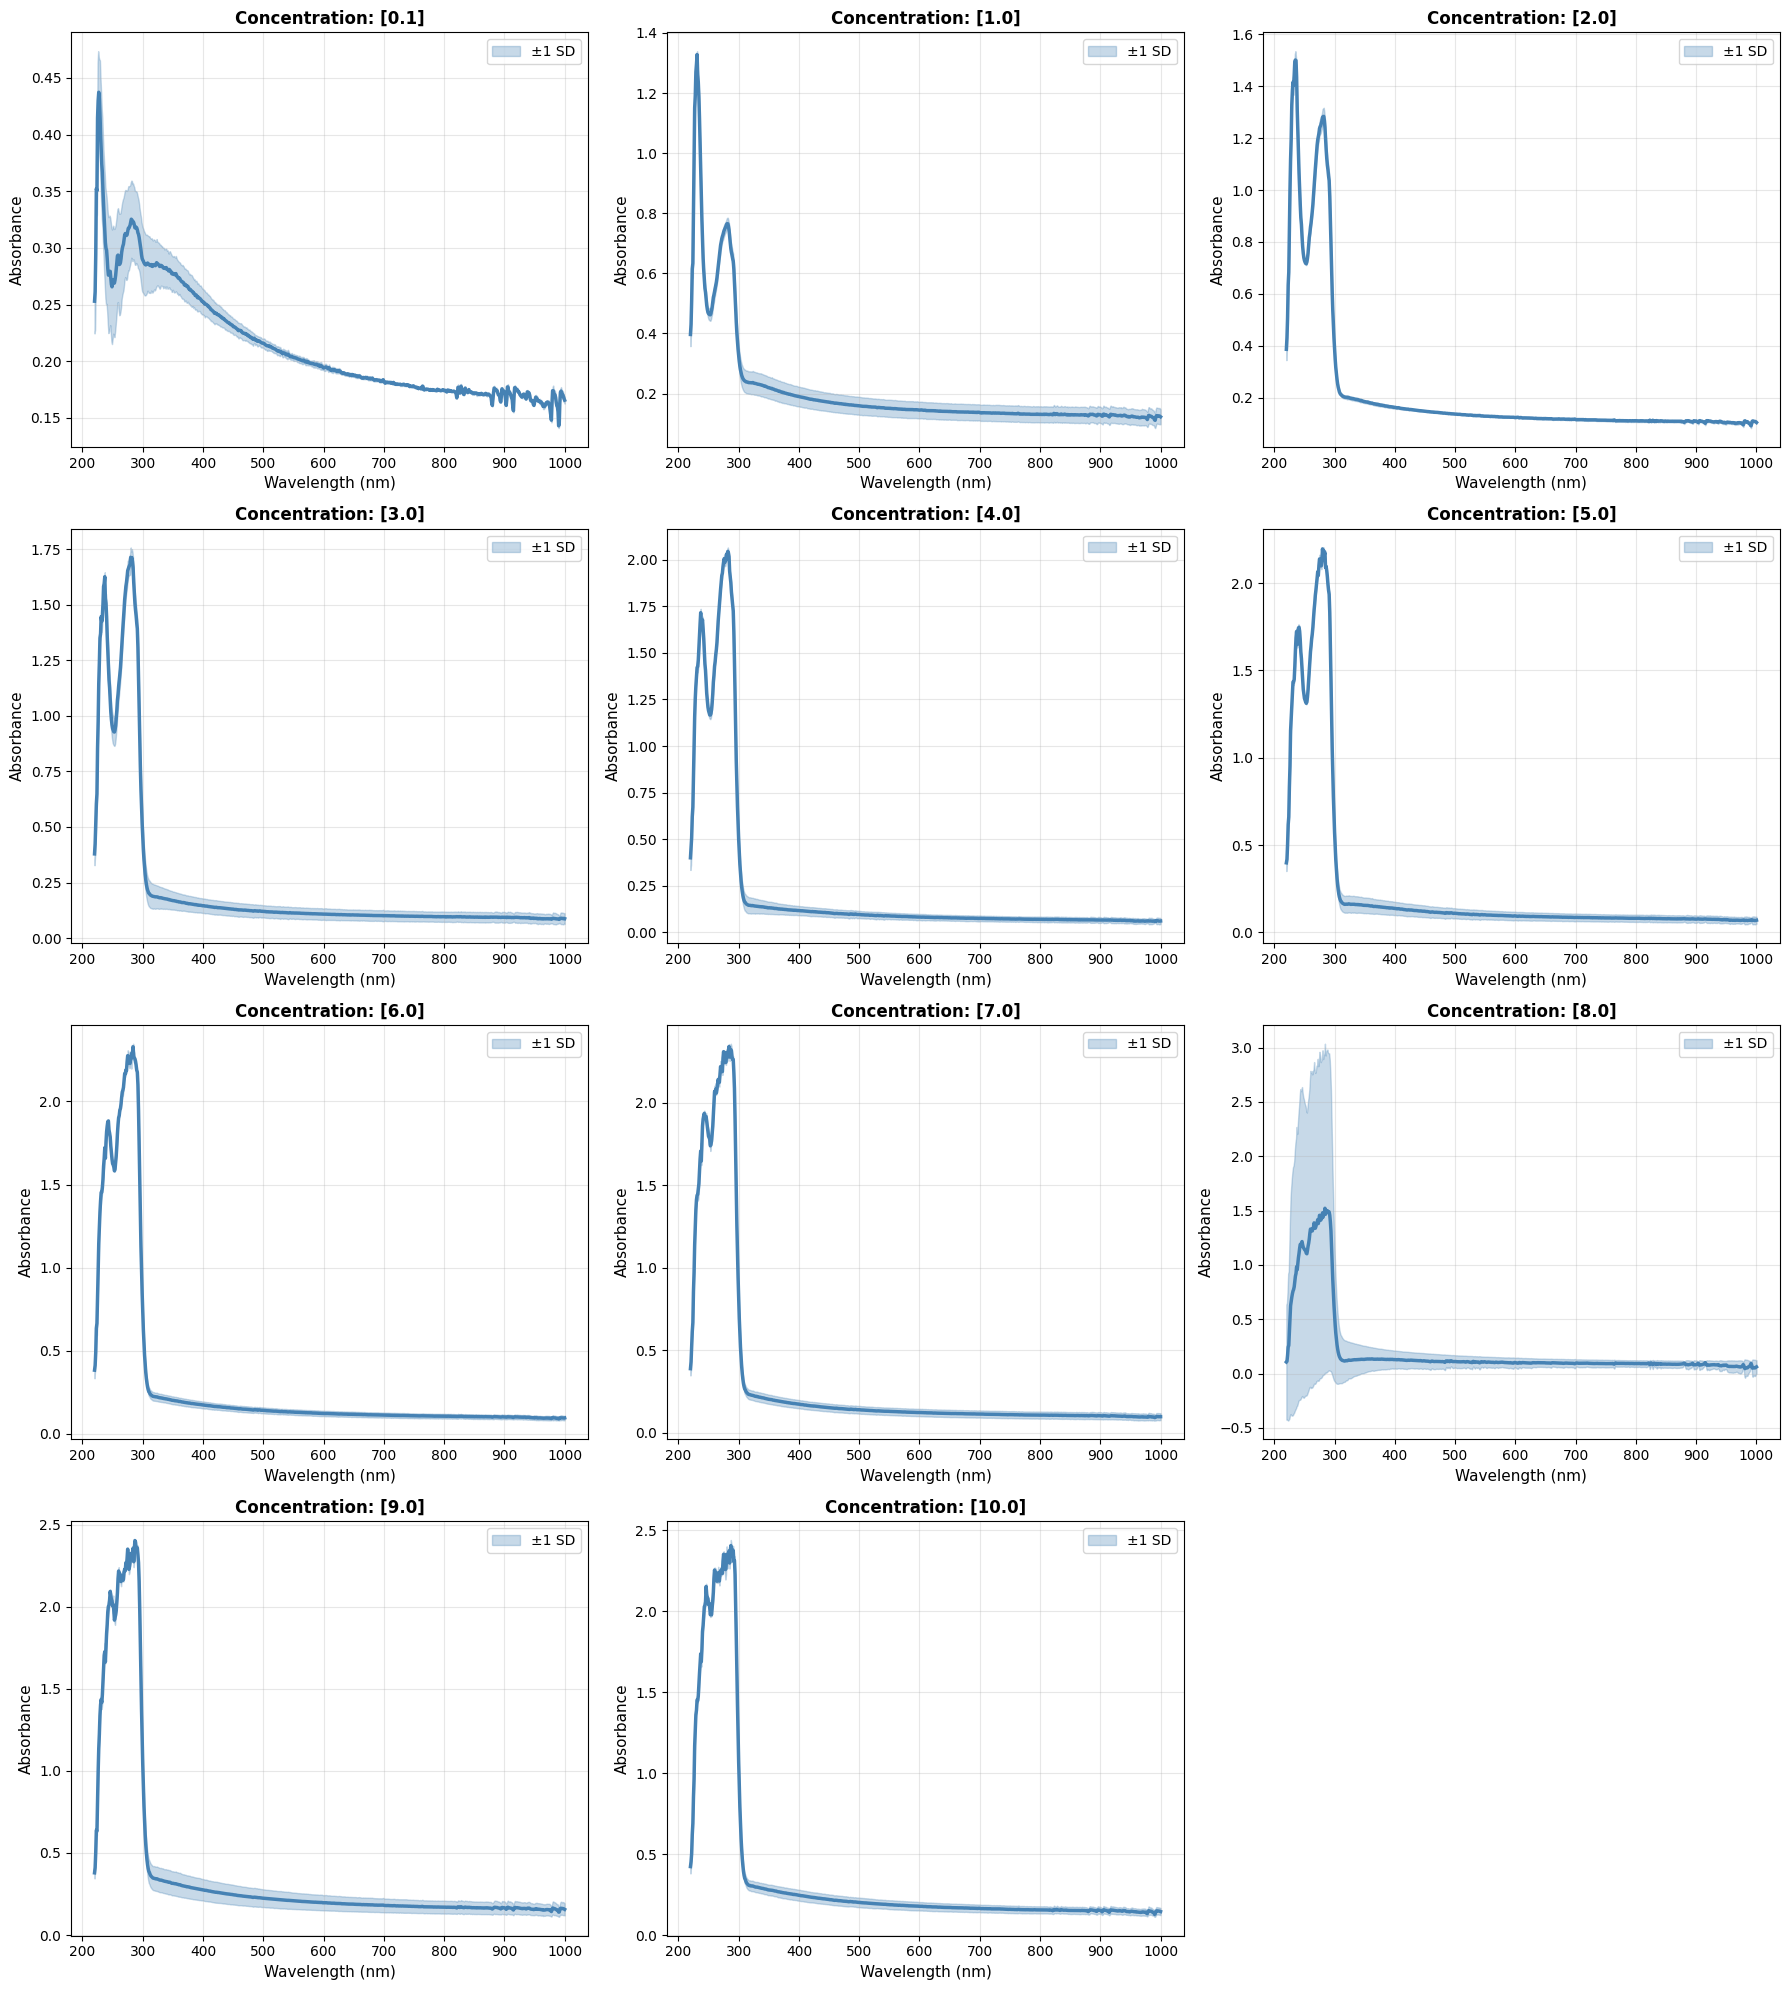

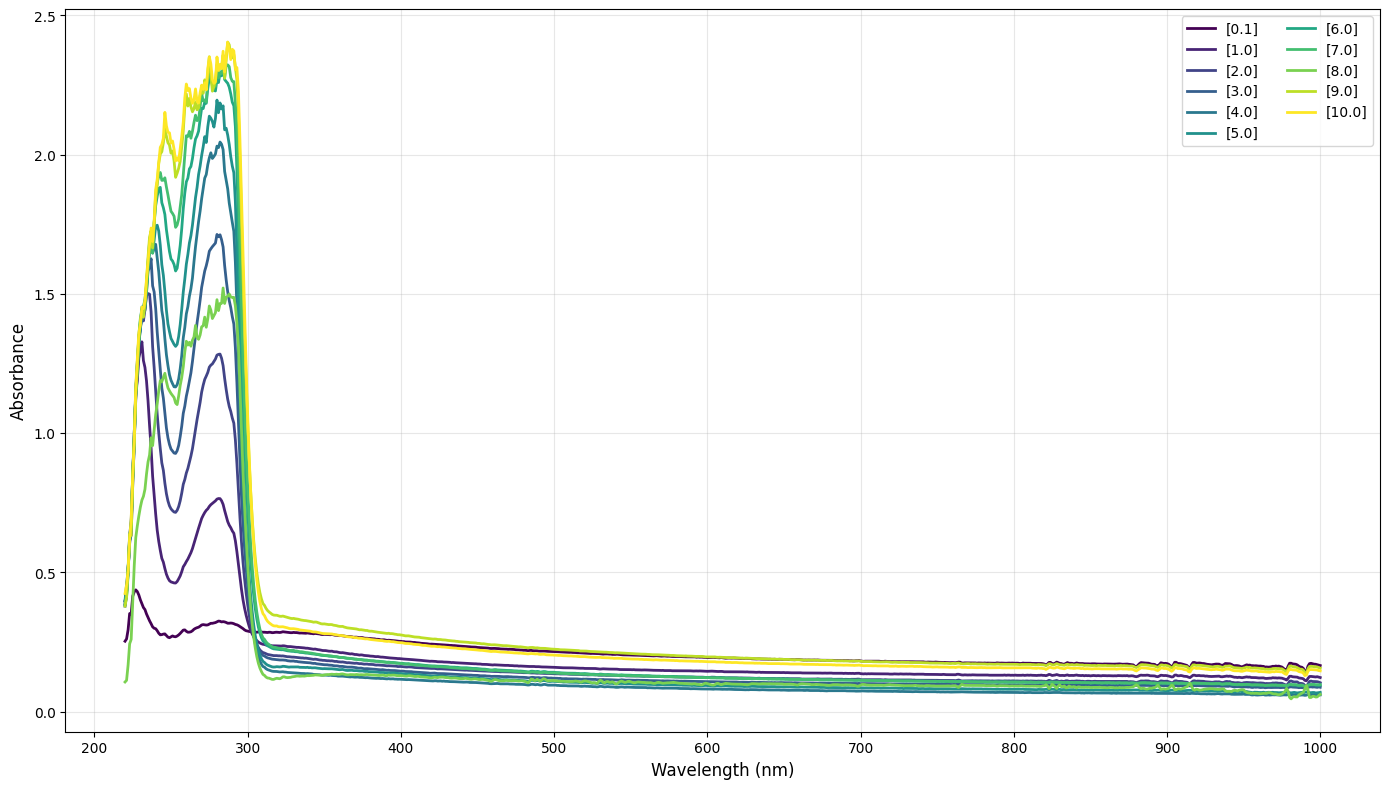

In [24]:
# Create individual plots for each concentration
concentrations = sorted(plot_for_plotting['content'].unique())
n_plots = len(concentrations)

# Create subplots for individual concentrations
fig_individual, axes = plt.subplots(n_rows := (n_plots + 2) // 3, 3, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for idx, conc in enumerate(concentrations):
    conc_data = plot_for_plotting[plot_for_plotting['content'] == conc].sort_values('wavelength')
    
    wavelengths_plot = conc_data['wavelength'].values
    mean_plot = conc_data['mean'].values
    std_plot = conc_data['std'].values
    
    ax = axes[idx]
    
    # Plot mean line
    ax.plot(wavelengths_plot, mean_plot, color='steelblue', linewidth=2.5)
    
    # Plot SD as shadow band
    ax.fill_between(wavelengths_plot, 
                     mean_plot - std_plot, 
                     mean_plot + std_plot, 
                     alpha=0.3, 
                     color='steelblue',
                     label='±1 SD')
    
    ax.set_xlabel('Wavelength (nm)', fontsize=11)
    ax.set_ylabel('Absorbance', fontsize=11)
    ax.set_title(f'Concentration: [{conc}]', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

# Remove extra subplots
for idx in range(n_plots, len(axes)):
    fig_individual.delaxes(axes[idx])

plt.tight_layout()
plt.show()

# Create overlay plot with all concentrations (no SD bands)
fig_overlay, ax_overlay = plt.subplots(figsize=(14, 8))

colors_overlay = plt.cm.viridis(np.linspace(0, 1, len(concentrations)))

for idx, conc in enumerate(concentrations):
    conc_data = plot_for_plotting[plot_for_plotting['content'] == conc].sort_values('wavelength')
    
    wavelengths_plot = conc_data['wavelength'].values
    mean_plot = conc_data['mean'].values
    
    # Plot mean line only
    ax_overlay.plot(wavelengths_plot, mean_plot, label=f'[{conc}]', 
                    color=colors_overlay[idx], linewidth=2)

ax_overlay.set_xlabel('Wavelength (nm)', fontsize=12)
ax_overlay.set_ylabel('Absorbance', fontsize=12)
ax_overlay.set_title('', fontsize=14)
ax_overlay.legend(loc='best', fontsize=10, ncol=2)
ax_overlay.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

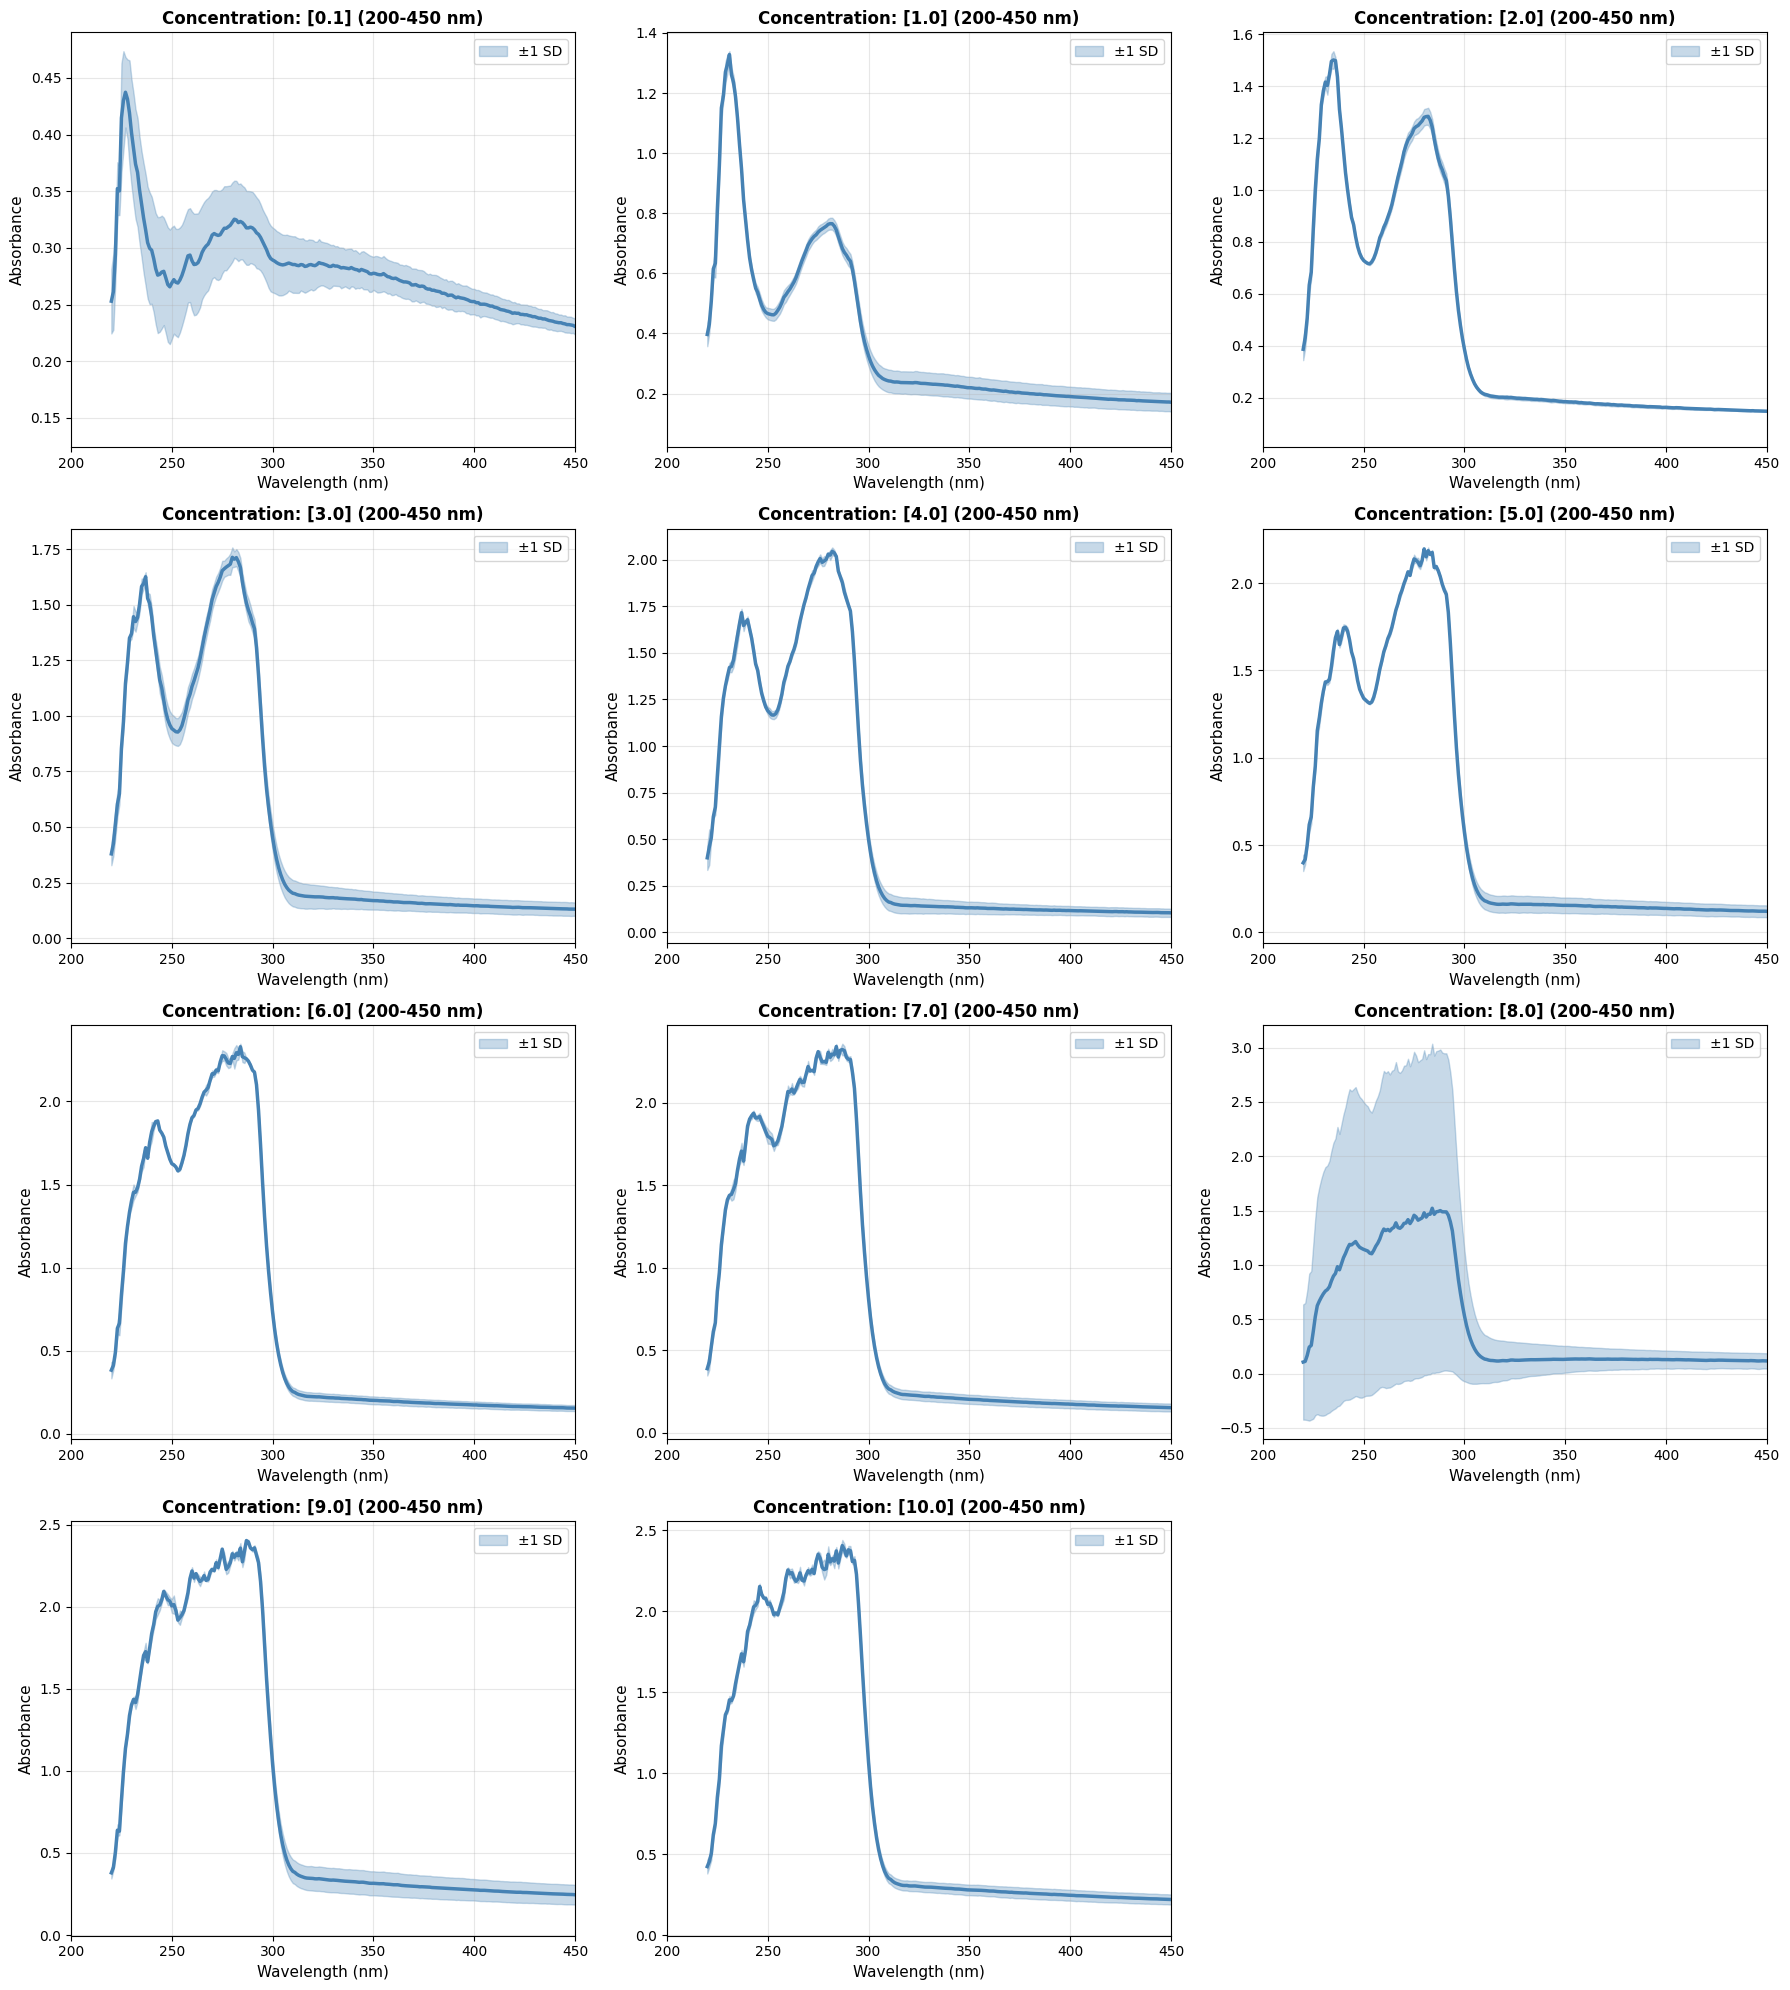

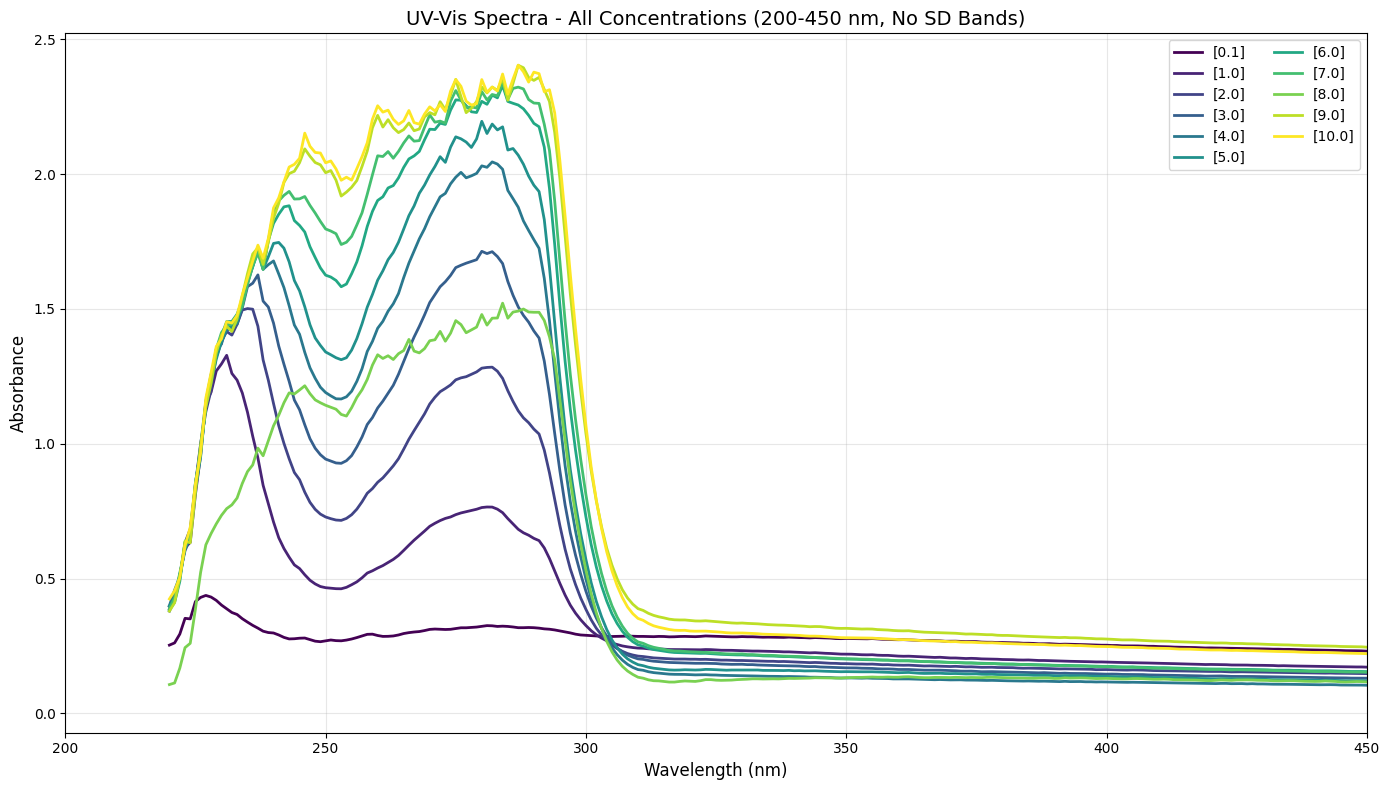

In [25]:
# Create individual plots for each concentration - ZOOMED TO 450 nm
concentrations = sorted(plot_for_plotting['content'].unique())
n_plots = len(concentrations)

# Create subplots for individual concentrations (450 nm cutoff)
fig_individual_450, axes_450 = plt.subplots(n_rows := (n_plots + 2) // 3, 3, figsize=(18, 5 * n_rows))
axes_450 = axes_450.flatten()

for idx, conc in enumerate(concentrations):
    conc_data = plot_for_plotting[plot_for_plotting['content'] == conc].sort_values('wavelength')
    
    wavelengths_plot = conc_data['wavelength'].values
    mean_plot = conc_data['mean'].values
    std_plot = conc_data['std'].values
    
    ax = axes_450[idx]
    
    # Plot mean line
    ax.plot(wavelengths_plot, mean_plot, color='steelblue', linewidth=2.5)
    
    # Plot SD as shadow band
    ax.fill_between(wavelengths_plot, 
                     mean_plot - std_plot, 
                     mean_plot + std_plot, 
                     alpha=0.3, 
                     color='steelblue',
                     label='±1 SD')
    
    ax.set_xlabel('Wavelength (nm)', fontsize=11)
    ax.set_ylabel('Absorbance', fontsize=11)
    ax.set_title(f'Concentration: [{conc}] (200-450 nm)', fontsize=12, fontweight='bold')
    ax.set_xlim(200, 450)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

# Remove extra subplots
for idx in range(n_plots, len(axes_450)):
    fig_individual_450.delaxes(axes_450[idx])

plt.tight_layout()
plt.show()

# Create overlay plot with all concentrations - ZOOMED TO 450 nm
fig_overlay_450, ax_overlay_450 = plt.subplots(figsize=(14, 8))

colors_overlay = plt.cm.viridis(np.linspace(0, 1, len(concentrations)))

for idx, conc in enumerate(concentrations):
    conc_data = plot_for_plotting[plot_for_plotting['content'] == conc].sort_values('wavelength')
    
    wavelengths_plot = conc_data['wavelength'].values
    mean_plot = conc_data['mean'].values
    
    # Plot mean line only
    ax_overlay_450.plot(wavelengths_plot, mean_plot, label=f'[{conc}]', 
                        color=colors_overlay[idx], linewidth=2)

ax_overlay_450.set_xlabel('Wavelength (nm)', fontsize=12)
ax_overlay_450.set_ylabel('Absorbance', fontsize=12)
ax_overlay_450.set_title('UV-Vis Spectra - All Concentrations (200-450 nm, No SD Bands)', fontsize=14)
ax_overlay_450.set_xlim(200, 450)
ax_overlay_450.legend(loc='best', fontsize=10, ncol=2)
ax_overlay_450.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()